# M2-B2 — Audit éthique Athéna RH — phase SYNC binôme

> **Mission** : audit éthique complet du dataset Adult Income enrichi de
> commentaires manager. Datasheet duo signée. La phase d'anonymisation
> personnelle se fera en async (notebook séparé).

Binôme : `<prénom1>` + `<prénom2>` — Date : `<date>`

**Conventions** :
- `random_state=42` partout
- Pas de `print` (utiliser `display()` ou laisser la cellule retourner)
- `pathlib.Path` sur les chemins

## 0. Setup

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42
DATA_DIR = Path("../data")
FULL_PATH = DATA_DIR / "adult_income_with_comments.csv"
SAMPLE_PATH = DATA_DIR / "audit_sample.csv"

sns.set_theme(style="whitegrid")

In [11]:
df = pd.read_csv(FULL_PATH)
print(f"Shape : {df.shape}")
df.head(3)

Shape : (32561, 16)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,manager_comments
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,RAS pour Alexandre Traore cette année. Manager...
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,Entretien annuel de Yves Traore : bon élément....
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,Alerte comportementale signalée par Gabriel de...


## 1. Audit qualité express (~15 min)

Le dataset Adult est plus propre que German Credit (peu de manquants).
Survol express ici — l'audit éthique est le cœur de M2-B2.

In [12]:
df.info()
print("\nManquants par colonne (top 5) :")
df.isna().sum().sort_values(ascending=False).head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   age               32561 non-null  int64 
 1   workclass         30725 non-null  object
 2   fnlwgt            32561 non-null  int64 
 3   education         32561 non-null  object
 4   education_num     32561 non-null  int64 
 5   marital_status    32561 non-null  object
 6   occupation        30718 non-null  object
 7   relationship      32561 non-null  object
 8   race              32561 non-null  object
 9   sex               32561 non-null  object
 10  capital_gain      32561 non-null  int64 
 11  capital_loss      32561 non-null  int64 
 12  hours_per_week    32561 non-null  int64 
 13  native_country    31978 non-null  object
 14  income            32561 non-null  object
 15  manager_comments  32561 non-null  object
dtypes: int64(6), object(10)
memory usage: 4.0+ MB

Manquants p

occupation        1843
workclass         1836
native_country     583
age                  0
fnlwgt               0
dtype: int64

## 2. Audit éthique complet (~1 h)

Calcul du **disparate impact** sur 3 variables sensibles + 1 intersection.

In [13]:
def disparate_impact(df: pd.DataFrame, sensible: str, target: str = "income",
                     positive: str = ">50K") -> tuple[float, pd.Series]:
    """Calcule le DI = SR_min / SR_max + retourne la série des SR par groupe."""
    sr = df.groupby(sensible)[target].apply(lambda x: (x == positive).mean())
    di = sr.min() / sr.max()
    return di, sr

In [14]:
# DI sur sex
di_sex, sr_sex = disparate_impact(df, 'sex')
display(di_sex)
sr_sex

0.3580225496813511

sex
Female    0.109461
Male      0.305737
Name: income, dtype: float64

In [15]:
# DI sur race
di_race, sr_race = disparate_impact(df, 'race')
display(di_race)
sr_race

0.34727792930103213

race
Amer-Indian-Eskimo    0.115756
Asian-Pac-Islander    0.265640
Black                 0.123880
Other                 0.092251
White                 0.255860
Name: income, dtype: float64

In [16]:
# DI sur native_country (agrégé en USA / non-USA pour simplifier)
df['native_us'] = (df['native_country'] == 'United-States').map({True: 'USA', False: 'non-USA'})
di_native_country, sr_native_country = disparate_impact(df, 'native_us')
display(di_native_country)
sr_native_country

0.8037180456803203

native_us
USA        0.245835
non-USA    0.197582
Name: income, dtype: float64

### Intersectionnalité — DI sur le croisement sex × race

In [17]:
# Créer une colonne sex_race et calculer le DI
df['sex_race'] = df['sex'].str.cat(df['race'], sep='_')
di_sex_race, sr_sex_race = disparate_impact(df, "sex_race")
display(di_sex_race)
sr_sex_race

0.1637201244241446

sex_race
Female_Amer-Indian-Eskimo    0.100840
Female_Asian-Pac-Islander    0.124277
Female_Black                 0.057878
Female_Other                 0.055046
Female_White                 0.118954
Male_Amer-Indian-Eskimo      0.125000
Male_Asian-Pac-Islander      0.336219
Male_Black                   0.189293
Male_Other                   0.117284
Male_White                   0.317565
Name: income, dtype: float64

## 3. Visualisations (≥ 5)

Au moins 5 visualisations : distribution cible + DI par variable sensible +
crosstab intersection.

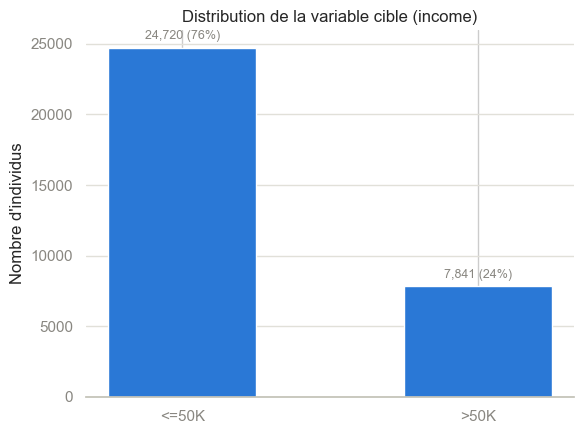

In [18]:
# Visualisation 1 — distribution de la cible (income)
COLOR_MAIN = "#2a78d6"  # slot 1 (bleu), série unique
MUTED = "#898781"
GRID = "#e1e0d9"
AXIS = "#c3c2b7"

income_counts = df["income"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(income_counts.index, income_counts.values, color=COLOR_MAIN, width=0.5)
ax.bar_label(
    bars,
    labels=[f"{v:,} ({v / income_counts.sum():.0%})" for v in income_counts.values],
    padding=4, fontsize=9, color=MUTED,
)

ax.set_ylabel("Nombre d'individus")
ax.set_title("Distribution de la variable cible (income)")
ax.grid(axis="y", color=GRID, linewidth=1)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(AXIS)
ax.tick_params(axis="x", colors=MUTED)
ax.tick_params(axis="y", colors=MUTED)

plt.tight_layout()
plt.show()

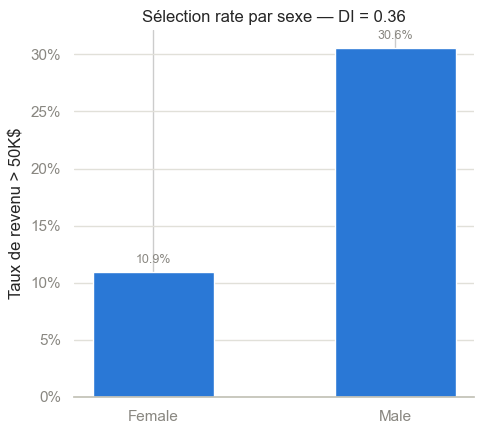

In [19]:
# Visualisation 2 — DI sur sex
fig, ax = plt.subplots(figsize=(5, 4.5))
bars = ax.bar(sr_sex.index, sr_sex.values, color=COLOR_MAIN, width=0.5)
ax.bar_label(bars, fmt=lambda v: f"{v:.1%}", padding=4, fontsize=9, color=MUTED)

ax.set_ylabel("Taux de revenu > 50K$")
ax.set_title(f"Sélection rate par sexe — DI = {di_sex:.2f}")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.grid(axis="y", color=GRID, linewidth=1)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(AXIS)
ax.tick_params(axis="x", colors=MUTED)
ax.tick_params(axis="y", colors=MUTED)

plt.tight_layout()
plt.show()

/var/folders/77/lnt41f0d22s5vkqgcf4wpghc0000gn/T/ipykernel_63749/2436614729.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sr_race_sorted.index, rotation=15, ha="right")


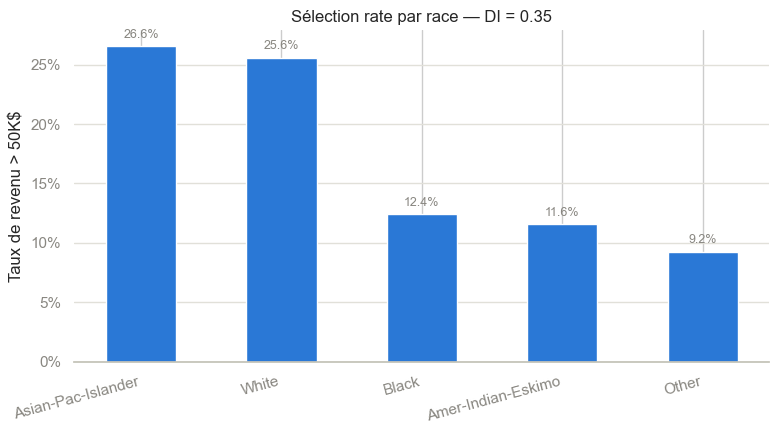

In [22]:
# Visualisation 3 — DI sur race
sr_race_sorted = sr_race.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(sr_race_sorted.index, sr_race_sorted.values, color=COLOR_MAIN, width=0.5)
ax.bar_label(bars, fmt=lambda v: f"{v:.1%}", padding=4, fontsize=9, color=MUTED)

ax.set_ylabel("Taux de revenu > 50K$")
ax.set_title(f"Sélection rate par race — DI = {di_race:.2f}")
ax.set_xticklabels(sr_race_sorted.index, rotation=15, ha="right")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.grid(axis="y", color=GRID, linewidth=1)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(AXIS)
ax.tick_params(axis="x", colors=MUTED)
ax.tick_params(axis="y", colors=MUTED)

plt.tight_layout()
plt.show()

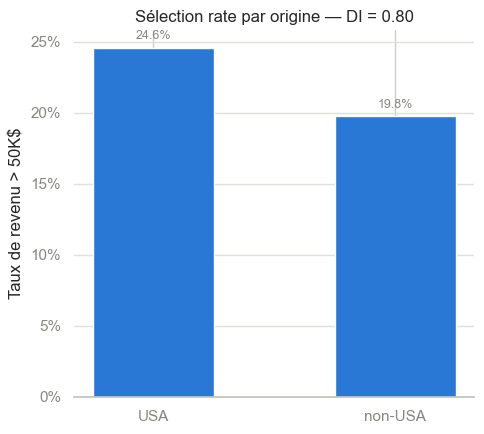

In [23]:
# Visualisation 4 — DI sur native_country (USA / non-USA)
fig, ax = plt.subplots(figsize=(5, 4.5))
bars = ax.bar(sr_native_country.index, sr_native_country.values, color=COLOR_MAIN, width=0.5)
ax.bar_label(bars, fmt=lambda v: f"{v:.1%}", padding=4, fontsize=9, color=MUTED)

ax.set_ylabel("Taux de revenu > 50K$")
ax.set_title(f"Sélection rate par origine — DI = {di_native_country:.2f}")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.grid(axis="y", color=GRID, linewidth=1)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(AXIS)
ax.tick_params(axis="x", colors=MUTED)
ax.tick_params(axis="y", colors=MUTED)

plt.tight_layout()
plt.show()

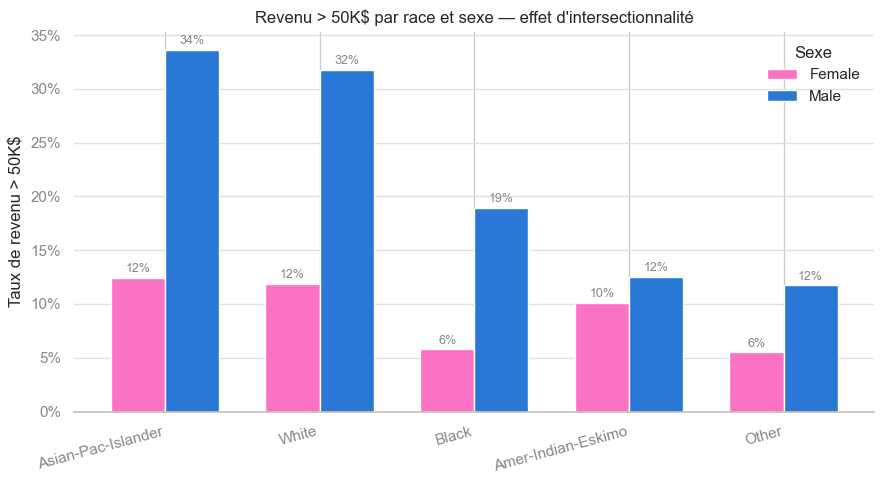

In [20]:
# Visualisation 1 — taux de revenu >50K par race x sexe
COLOR_MALE = "#2a78d6"  # slot 1 (bleu)
COLOR_FEMALE = "#FB72C4"    # slot 2 (vert)
MUTED = "#898781"
GRID = "#e1e0d9"
AXIS = "#c3c2b7"

pivot_race_sex = (
    df.groupby(["race", "sex"])["income"]
    .apply(lambda x: (x == ">50K").mean())
    .unstack("sex")
)
# tri par taux moyen décroissant pour faciliter la lecture
pivot_race_sex = pivot_race_sex.loc[pivot_race_sex.mean(axis=1).sort_values(ascending=False).index]

races = pivot_race_sex.index
x = np.arange(len(races))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars_f = ax.bar(x - width / 2, pivot_race_sex["Female"], width, label="Female", color=COLOR_FEMALE)
bars_m = ax.bar(x + width / 2, pivot_race_sex["Male"], width, label="Male", color=COLOR_MALE)

ax.bar_label(bars_f, fmt=lambda v: f"{v:.0%}", padding=2, fontsize=9, color=MUTED)
ax.bar_label(bars_m, fmt=lambda v: f"{v:.0%}", padding=2, fontsize=9, color=MUTED)

ax.set_xticks(x)
ax.set_xticklabels(races, rotation=15, ha="right")
ax.set_ylabel("Taux de revenu > 50K$")
ax.set_title("Revenu > 50K$ par race et sexe — effet d'intersectionnalité")

ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.grid(axis="y", color=GRID, linewidth=1)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(AXIS)
ax.tick_params(axis="x", colors=MUTED)
ax.tick_params(axis="y", colors=MUTED)

ax.legend(title="Sexe", frameon=False)
plt.tight_layout()
plt.show()

## 4. Verdict éthique (paragraphe markdown)

> Court paragraphe : « Quels biais structurels avons-nous détectés ? Quel
> est le DI le plus problématique ? »

À recopier dans `../datasheet.md` (section *Composition* / *Risques*).

Nous avons détecté un biais raciste en faveur des asiatiques / blancs (avec un DI de 0.347) et un biais sexiste en faveur des hommes (avec un DI de 0.358). Les valeurs de DI sont particulièrement extrèmes la borne limite inférieure acceptable étant de 0.80.

## 5. Aperçu de la colonne `manager_comments` (pour préparer l'async)

In [21]:
# Quelques exemples pour identifier les types de PII
for i in range(5):
    print(f'--- Exemple {i+1} ---')
    print(df['manager_comments'].iloc[i])
    print()

--- Exemple 1 ---
RAS pour Alexandre Traore cette année. Manager : Gérard-Frédéric Joly.

--- Exemple 2 ---
Entretien annuel de Yves Traore : bon élément. Référent : Aurore Maury-Briand, joignable au 654.235.1161.

--- Exemple 3 ---
Alerte comportementale signalée par Gabriel de Guilbert au sujet de Alexandre Morin. Suivi RH : maria95@example.net.

--- Exemple 4 ---
Mobilité demandée par Victor du Vasseur. Validée par Laurence Robert le 2025-08-28. Ticket HR-67242.

--- Exemple 5 ---
Prime versée à Marcel Leblanc sur le compte ****0122. Contrôle : Denis-Franck Ledoux.



## 6. Datasheet binôme (à compléter dans `../datasheet.md`)

Reprendre la structure Gebru — 7 sections, 2 pages max. Signée duo
(« Auteurs : <prénom1>, <prénom2> » en haut).